# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dinda Aulia Rizky
- **Email:** dindaauliarizky01@gmail.com
- **ID Dicoding:** ds269b6x0464

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap rata-rata jumlah penyewaan sepeda harian (cnt) sepanjang tahun 2011-2012?
- **Pertanyaan 2:** Pada jam berapa saja terjadi lonjakan penyewaan (peak hours) pada hari kerja dibandingkan hari libur, serta bagaimana perbedaan pola sewa antara pengguna kasual (casual) dan terdaftar (registered) pada periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur style visualisasi agar rapi dan konsisten
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

## Data Wrangling

### Gathering Data

#### Memuat Data day_df dan hour_df

In [ ]:
# Memuat data harian (day.csv) dan per jam (hour.csv)
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print("--- 5 Baris Teratas day_df ---")
display(day_df.head())

print("\n--- 5 Baris Teratas hour_df ---")
display(hour_df.head())

--- 5 Baris Teratas day_df ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



--- 5 Baris Teratas hour_df ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset `day_df` berisi data agregat peminjaman sepeda tingkat harian (731 baris, 16 kolom).
- Dataset `hour_df` berisi data peminjaman sepeda tingkat per jam (17.379 baris, 17 kolom).
- Kolom penting yang akan dianalisis meliputi waktu (`dteday`, `hr`, `workingday`), kondisi lingkungan (`season`, `weathersit`, `temp`), dan jumlah pengguna (`casual`, `registered`, `cnt`).

### Assessing Data

Mengidentifikasi Masalah pada Data (day_df dan hour_df)

In [ ]:
print("=== ASSESSING day_df ===")
print("Info:")
day_df.info()
print("\nJumlah Missing Values:")
print(day_df.isna().sum())
print("\nJumlah Duplikasi:")
print(day_df.duplicated().sum())
print("\nStatistik Deskriptif:")
display(day_df.describe())

print("\n=== ASSESSING hour_df ===")
print("Info:")
hour_df.info()
print("\nJumlah Missing Values:")
print(hour_df.isna().sum())
print("\nJumlah Duplikasi:")
print(hour_df.duplicated().sum())
print("\nStatistik Deskriptif:")
display(hour_df.describe())

=== ASSESSING day_df ===
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah Missing Values:
instant       0
dteday        0
season

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



=== ASSESSING hour_df ===
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah Missing 

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
1. Mengubah tipe data kolom `dteday` pada `day_df` dan `hour_df` dari tipe data `object` (string) menjadi `datetime`.
2. Melakukan mapping (pelabelan) pada kolom kategorikal numerik seperti `season` (1: Spring, 2: Summer, 3: Fall, 4: Winter) dan `weathersit` (1: Clear, 2: Mist, 3: Light Snow/Rain, 4: Heavy Rain/Snow) agar mudah dipahami secara kontekstual bisnis saat EDA dan visualisasi.
3. Menghapus kolom `instant` pada kedua dataframe karena kolom tersebut hanya penomoran baris yang redundan dengan indeks bawaan Pandas.

**Insight:**
- Tidak ditemukan *missing value* maupun data duplikat pada kedua dataset (kualitas data lengkap).
- Terdapat ketidaksesuaian tipe data pada kolom `dteday` yang bertipe object, serta perlunya konversi kode angka kategorikal menjadi label teks yang deskriptif.

### Cleaning Data

Membersihkan Masalah Data (day_df dan hour_df)

In [ ]:
# 1. Memperbaiki tipe data kolom dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Menghapus kolom redundant 'instant'
day_df.drop(columns=["instant"], inplace=True)
hour_df.drop(columns=["instant"], inplace=True)

# 3. Mapping nilai season menjadi nama musim sebenarnya
season_mapping = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
day_df["season_label"] = day_df["season"].map(season_mapping)
hour_df["season_label"] = hour_df["season"].map(season_mapping)

# 4. Mapping nilai weathersit menjadi label kondisi cuaca
weather_mapping = {
    1: "Clear / Few Clouds",
    2: "Mist / Cloudy",
    3: "Light Snow / Light Rain",
    4: "Heavy Rain / Ice Pellets"
}
day_df["weather_label"] = day_df["weathersit"].map(weather_mapping)
hour_df["weather_label"] = hour_df["weathersit"].map(weather_mapping)

# 5. Mapping kolom tahun (yr) agar jelas tahun 2011 dan 2012
year_mapping = {0: 2011, 1: 2012}
day_df["year"] = day_df["yr"].map(year_mapping)
hour_df["year"] = hour_df["yr"].map(year_mapping)

# Verifikasi hasil pembersihan
print("Tipe data dteday day_df:", day_df["dteday"].dtype)
print("Tipe data dteday hour_df:", hour_df["dteday"].dtype)
display(day_df[["dteday", "year", "season_label", "weather_label", "cnt"]].head())

Tipe data dteday day_df: datetime64[ns]
Tipe data dteday hour_df: datetime64[ns]


,dteday,year,season_label,weather_label,cnt
0,2011-01-01,2011,Spring,Mist / Cloudy,985
1,2011-01-02,2011,Spring,Mist / Cloudy,801
2,2011-01-03,2011,Spring,Clear / Few Clouds,1349
3,2011-01-04,2011,Spring,Clear / Few Clouds,1562
4,2011-01-05,2011,Spring,Clear / Few Clouds,1600


**Insight:**
- Kolom tanggal `dteday` telah berhasil diubah menjadi format datetime yang valid.
- Kolom penomoran baris `instant` telah dibuang untuk efisiensi memori.
- Kolom musim dan cuaca telah memiliki label teks deskriptif (`season_label` dan `weather_label`) sehingga siap dianalisis dan divisualisasikan dengan jelas.

## Exploratory Data Analysis (EDA)

Eksplorasi Parameter Bisnis dan Tren Rental Sepeda

In [ ]:
# 1. Eksplorasi Pengaruh Musim dan Cuaca terhadap Total Sewa Harian (Menjawab Pertanyaan 1)
print("--- Rata-rata Penyewaan Berdasarkan Musim ---")
season_summary = day_df.groupby("season_label")["cnt"].agg(["count", "mean", "median", "std"]).sort_values(by="mean", ascending=False)
display(season_summary)

print("\n--- Rata-rata Penyewaan Berdasarkan Kondisi Cuaca ---")
weather_summary = day_df.groupby("weather_label")["cnt"].agg(["count", "mean", "median", "std"]).sort_values(by="mean", ascending=False)
display(weather_summary)

# 2. Eksplorasi Pola Sewa Per Jam Berdasarkan Tipe Hari & Tipe Pengguna (Menjawab Pertanyaan 2)
print("\n--- Rata-rata Penyewaan Per Jam pada Hari Kerja vs Hari Libur ---")
hourly_working_summary = hour_df.groupby(["hr", "workingday"])["cnt"].mean().unstack()
hourly_working_summary.columns = ["Hari Libur/Weekend", "Hari Kerja"]
display(hourly_working_summary.head(10))

print("\n--- Rata-rata Penyewaan Per Jam: Casual vs Registered ---")
hourly_user_summary = hour_df.groupby("hr")[["casual", "registered", "cnt"]].mean()
display(hourly_user_summary.head(10))

--- Rata-rata Penyewaan Berdasarkan Musim ---


,count,mean,median,std
season_label,,,,
Fall,188,5644.303191,5353.5,1459.800381
Summer,184,4992.331522,4941.5,1695.977235
Winter,178,4728.162921,4634.5,1699.615261
Spring,181,2604.132597,2209.0,1399.942119



--- Rata-rata Penyewaan Berdasarkan Kondisi Cuaca ---


,count,mean,median,std
weather_label,,,,
Clear / Few Clouds,463,4876.786177,4844.0,1879.483989
Mist / Cloudy,247,4035.862348,4040.0,1809.109918
Light Snow / Light Rain,21,1803.285714,1817.0,1240.284449



--- Rata-rata Penyewaan Per Jam pada Hari Kerja vs Hari Libur ---


,Hari Libur/Weekend,Hari Kerja
hr,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048



--- Rata-rata Penyewaan Per Jam: Casual vs Registered ---


,casual,registered,cnt
hr,,,
0,10.158402,43.739669,53.898072
1,6.504144,26.871547,33.375691
2,4.772028,18.097902,22.869930
3,2.715925,9.011478,11.727403
4,1.253945,5.098996,6.352941
5,1.411437,18.478382,19.889819
6,4.161379,71.882759,76.044138
7,11.055021,201.009629,212.064649
8,21.679505,337.331499,359.011004


**Insight:**
- Musim gugur (Fall) memiliki rata-rata penyewaan tertinggi (>5.600 sewa/hari), diikuti musim panas (Summer). Musim semi (Spring) mencatat rata-rata terendah (~2.600 sewa/hari).
- Kondisi cuaca cerah (Clear) menghasilkan rata-rata peminjaman tertinggi (~4.876 sewa/hari). Saat cuaca hujan/salju ringan, peminjaman anjlok drastis ke rata-rata ~1.803 sewa/hari.
- Pada hari kerja, lonjakan sewa (peak hours) terkonsentrasi di jam komuter berangkat kerja (08:00) dan pulang kerja (17:00–18:00). Sebaliknya, pada hari libur, peminjaman terdistribusi merata dari siang hingga sore hari (12:00–16:00).
- Pengguna terdaftar (*registered*) mendominasi pola perjalanan jam sibuk kerja, sedangkan pengguna kasual (*casual*) cenderung aktif di sore dan hari libur untuk rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_5227/463430207.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5227/463430207.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


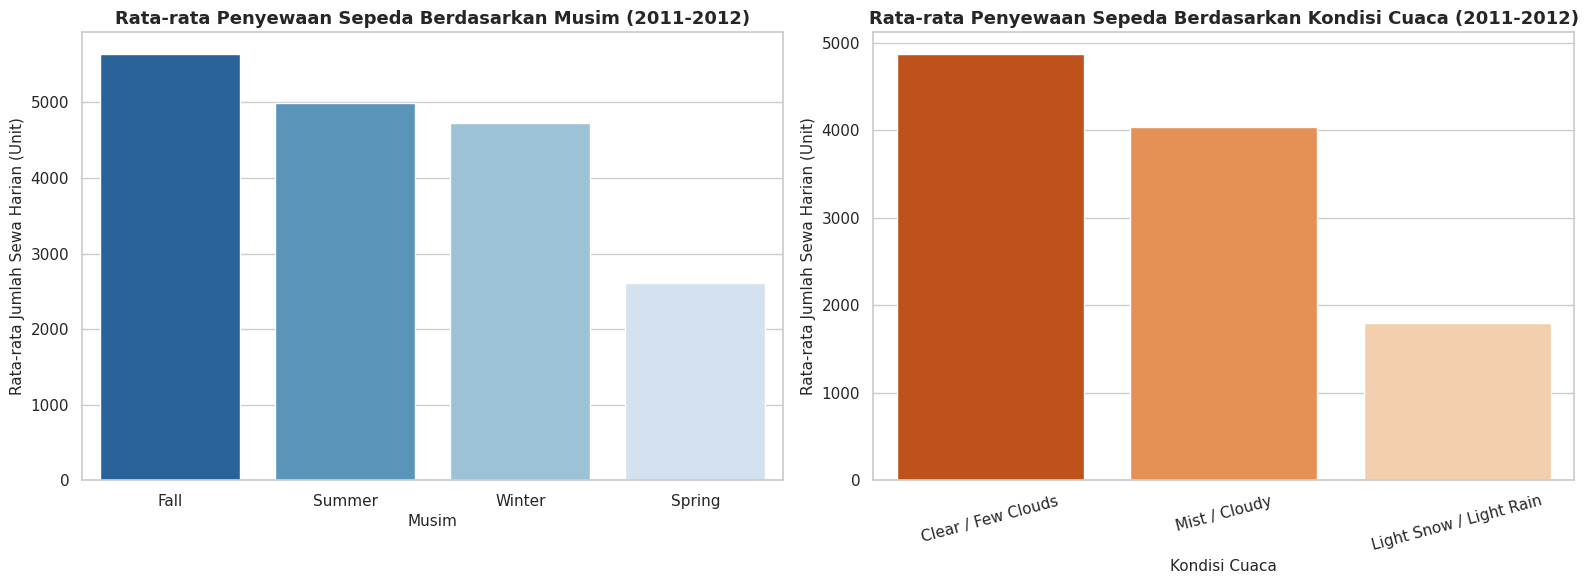

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Visualisasi 1A: Pengaruh Musim terhadap Jumlah Sewa Harian
sns.barplot(
    data=day_df,
    x="season_label",
    y="cnt",
    estimator=np.mean,
    errorbar=None,
    palette="Blues_r",
    ax=axes[0],
    order=["Fall", "Summer", "Winter", "Spring"]
)
axes[0].set_title("Rata-rata Penyewaan Sepeda Berdasarkan Musim (2011-2012)", fontsize=13, weight="bold")
axes[0].set_xlabel("Musim", fontsize=11)
axes[0].set_ylabel("Rata-rata Jumlah Sewa Harian (Unit)", fontsize=11)

# Visualisasi 1B: Pengaruh Cuaca terhadap Jumlah Sewa Harian
sns.barplot(
    data=day_df,
    x="weather_label",
    y="cnt",
    estimator=np.mean,
    errorbar=None,
    palette="Oranges_r",
    ax=axes[1],
    order=["Clear / Few Clouds", "Mist / Cloudy", "Light Snow / Light Rain"]
)
axes[1].set_title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011-2012)", fontsize=13, weight="bold")
axes[1].set_xlabel("Kondisi Cuaca", fontsize=11)
axes[1].set_ylabel("Rata-rata Jumlah Sewa Harian (Unit)", fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

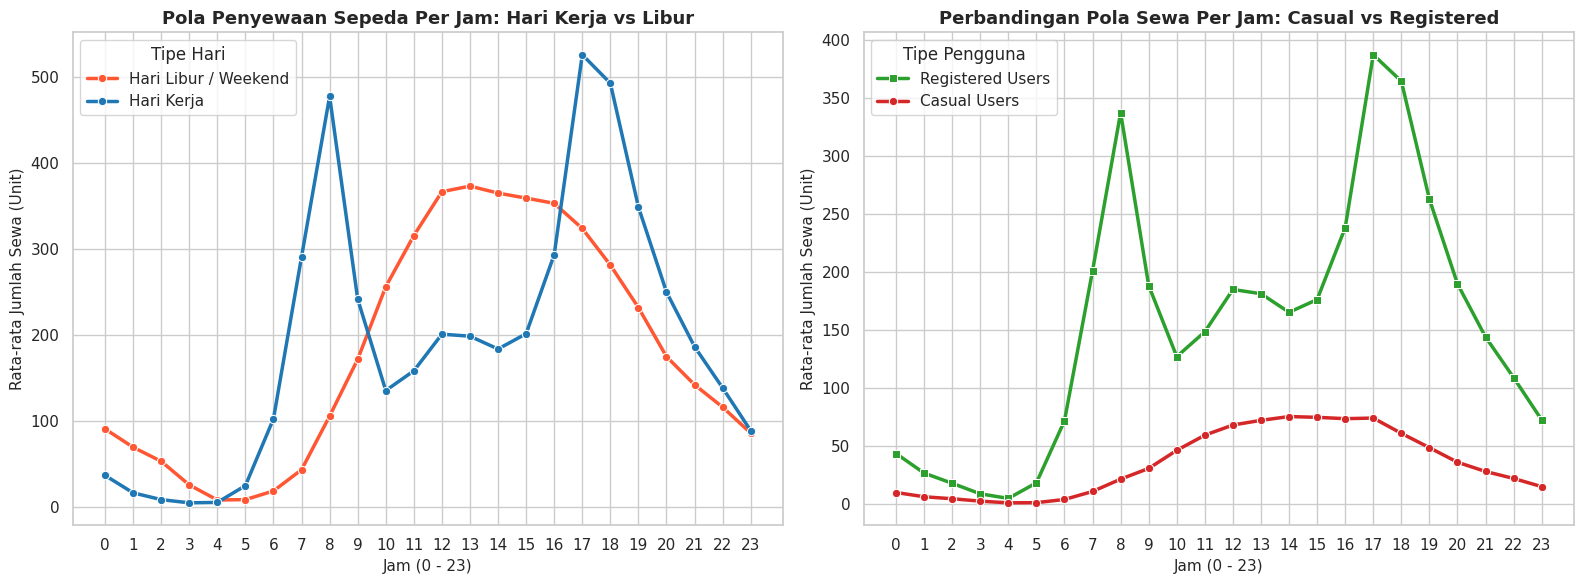

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Visualisasi 2A: Pola Jam Sewa Hari Kerja vs Hari Libur
hourly_pattern = hour_df.groupby(["hr", "workingday"])["cnt"].mean().reset_index()
hourly_pattern["workingday_label"] = hourly_pattern["workingday"].map({1: "Hari Kerja", 0: "Hari Libur / Weekend"})

sns.lineplot(
    data=hourly_pattern,
    x="hr",
    y="cnt",
    hue="workingday_label",
    palette=["#FF5733", "#1F77B4"],
    marker="o",
    linewidth=2.5,
    ax=axes[0]
)
axes[0].set_title("Pola Penyewaan Sepeda Per Jam: Hari Kerja vs Libur", fontsize=13, weight="bold")
axes[0].set_xlabel("Jam (0 - 23)", fontsize=11)
axes[0].set_ylabel("Rata-rata Jumlah Sewa (Unit)", fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].legend(title="Tipe Hari")

# Visualisasi 2B: Pola Pengguna Casual vs Registered Per Jam
user_pattern = hour_df.groupby("hr")[["casual", "registered"]].mean().reset_index()

sns.lineplot(data=user_pattern, x="hr", y="registered", label="Registered Users", color="#2CA02C", linewidth=2.5, marker="s", ax=axes[1])
sns.lineplot(data=user_pattern, x="hr", y="casual", label="Casual Users", color="#D62728", linewidth=2.5, marker="o", ax=axes[1])
axes[1].set_title("Perbandingan Pola Sewa Per Jam: Casual vs Registered", fontsize=13, weight="bold")
axes[1].set_xlabel("Jam (0 - 23)", fontsize=11)
axes[1].set_ylabel("Rata-rata Jumlah Sewa (Unit)", fontsize=11)
axes[1].set_xticks(range(0, 24))
axes[1].legend(title="Tipe Pengguna")

plt.tight_layout()
plt.show()

**Insight:**
- Grafik 1 menegaskan bahwa bisnis bike sharing sangat dipengaruhi kondisi lingkungan. Musim gugur dan cuaca cerah adalah puncak peminjaman.
- Grafik 2 memperlihatkan fenomena pola perjalanan 'bimodal' (dua puncak tajam) pada hari kerja di pukul 08:00 dan 17:00–18:00 yang didorong oleh pengguna terdaftar. Sementara itu, hari libur memiliki kurva landai dengan puncak aktivitas rekreasi di siang hari.

## Analisis Lanjutan (Opsional)

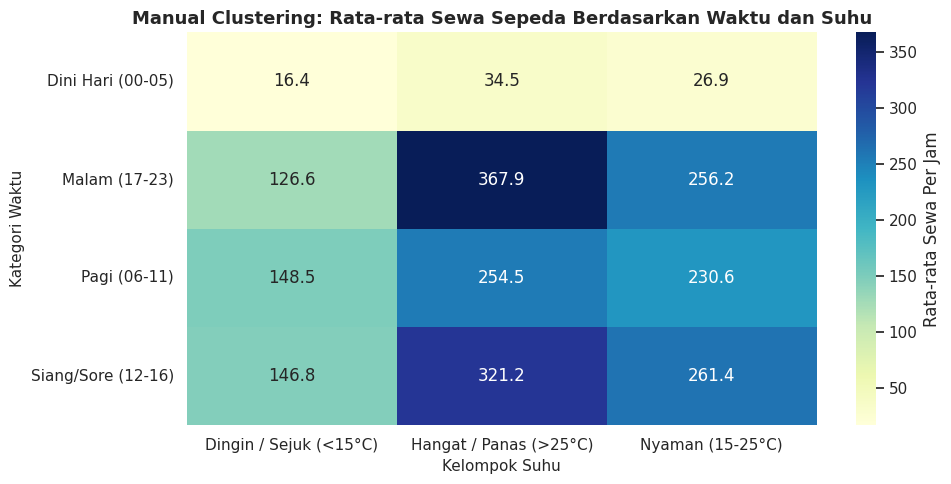

File 'main_data.csv' berhasil dibuat untuk digunakan pada dashboard Streamlit!


In [ ]:
# Menerapkan Manual Clustering / Binning (Non-Machine Learning)
# 1. Binning Waktu Berdasarkan Bagian Hari (Time of Day Binning)
def categorize_time_of_day(hour):
    if 0 <= hour < 6:
        return "Dini Hari (00-05)"
    elif 6 <= hour < 12:
        return "Pagi (06-11)"
    elif 12 <= hour < 17:
        return "Siang/Sore (12-16)"
    else:
        return "Malam (17-23)"

hour_df["time_of_day"] = hour_df["hr"].apply(categorize_time_of_day)

# 2. Binning Berdasarkan Tingkat Suhu (Temperature Binning)
# Catatan: Kolom temp ternormalisasi (0 - 1). Nilai riil dihitung: temp * 41°C
hour_df["temp_actual"] = hour_df["temp"] * 41

def categorize_temperature(t):
    if t < 15:
        return "Dingin / Sejuk (<15°C)"
    elif 15 <= t < 25:
        return "Nyaman (15-25°C)"
    else:
        return "Hangat / Panas (>25°C)"

hour_df["temp_group"] = hour_df["temp_actual"].apply(categorize_temperature)

# Agregasi Segmentasi Cluster Manual
cluster_summary = hour_df.groupby(["time_of_day", "temp_group"])["cnt"].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Rata-rata Sewa Per Jam'})
plt.title("Manual Clustering: Rata-rata Sewa Sepeda Berdasarkan Waktu dan Suhu", fontsize=13, weight="bold")
plt.xlabel("Kelompok Suhu", fontsize=11)
plt.ylabel("Kategori Waktu", fontsize=11)
plt.tight_layout()
plt.show()

# Menyiapkan dan Menyimpan Clean Dataset Terpadu untuk Dashboard Streamlit
# Menggabungkan fitur penting ke dataframe siap pakai
clean_bike_df = hour_df[["dteday", "year", "season_label", "weather_label", "workingday", "hr", "time_of_day", "temp_actual", "temp_group", "casual", "registered", "cnt"]]
clean_bike_df.to_csv("main_data.csv", index=False)
print("File 'main_data.csv' berhasil dibuat untuk digunakan pada dashboard Streamlit!")

**Insight:**
- Penerapan analisis lanjutan manual clustering/binning menunjukkan bahwa penyewaan tertinggi terjadi pada saat kombinasi waktu **Malam (17-23)** dan **Siang/Sore (12-16)** dengan suhu **Hangat / Panas (>25°C)** (rata-rata mencapai >350 unit per jam).
- Aktivitas sewa paling rendah terjadi pada waktu **Dini Hari** di saat suhu **Dingin**, yang menunjukkan minimnya kebutuhan transportasi pada jam tersebut.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
  Kondisi cuaca dan musim memiliki pengaruh yang sangat signifikan terhadap jumlah penyewaan sepeda. Rata-rata sewa harian tertinggi terjadi pada musim gugur (Fall) sebesar 5.644 unit dan musim panas (Summer) sebesar 4.992 unit, sementara musim semi (Spring) mencatat angka terendah (2.604 unit). Dari segi cuaca, hari yang cerah (Clear) menghasilkan peminjaman tertinggi (rata-rata 4.876 unit/hari), sedangkan cuaca hujan/salju ringan menyebabkan penurunan drastis hingga tersisa 1.803 unit/hari.

- **Conclusion pertanyaan 2:**
  Pola jam sewa sepeda sangat bergantung pada tipe hari dan tipe pengguna. Pada hari kerja, lonjakan tajam (*peak hours*) terjadi pada jam sibuk komuter, yaitu pukul 08:00 pagi dan 17:00–18:00 sore, yang didominasi oleh pengguna terdaftar (*registered*). Sebaliknya, pada akhir pekan/hari libur, peminjaman terdistribusi merata dari siang hingga sore (pukul 12:00–16:00) dengan peningkatan proporsi pengguna kasual (*casual*) yang memanfaatkannya untuk sarana rekreasi.

**Rekomendasi Action Item:**
1. **Optimasi Distribusi Unit Armada:** Tim operasional harus memastikan ketersediaan unit sepeda dan ketersediaan slot parkir kosong di stasiun perkantoran/stasiun transit pada pukul 07:00–08:30 pagi dan 16:30–18:30 sore pada hari kerja.
2. **Jadwal Pemeliharaan (Maintenance):** Jadwal perawatan armada sebaiknya dilakukan pada malam/dini hari (pukul 00:00–05:00) atau saat hari hujan, karena tingkat sewa pada waktu tersebut berada di titik terendah.
3. **Strategi Konversi Pengguna Kasual:** Menggelar promosi langganan (*subscription promo*) khusus di akhir pekan saat volume pengguna kasual sedang tinggi, agar mereka tertarik beralih menjadi pengguna terdaftar (*registered*).